In [1]:
import torch
import torchvision
from torch import nn, optim
import visionutils.transforms as T
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from utils.nn import ClusterDataset

import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import os
import pathlib
from pathlib import Path

%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# Hyperparameters
learning_rate = 1e-3
batch_size = 64
epochs = 10
keep_prob = 1

### Getting, Splitting, and transforming data

In [285]:
class WebskyDataset(torch.utils.data.Dataset):
    def __init__(self, root:str, cluster_dir:str, mask_dir:str, transforms=None):
        # directory to cluster and masks directory 
        self.root = root
        self.transforms = transforms
        self.cluster_dir = cluster_dir
        self.mask_dir = mask_dir

        self.imgs = list(sorted(os.listdir(os.path.join(root, self.cluster_dir))))
        self.masks = list(sorted(os.listdir(os.path.join(root, self.mask_dir))))

    # overwriting __getitem__()
    def __getitem__(self, idx):
        
        # loading images and masks
        img_path = os.path.join(self.root, self.cluster_dir, self.imgs[idx])
        mask_path = os.path.join(self.root, self.mask_dir, self.masks[idx])
        
        with fits.open(img_path) as hdu:
            imgs = hdu[0].data
            imgs = np.array(imgs, dtype='f')

        with np.load(mask_path) as data:
            masks = data['arr_0']
            masks = np.array(masks)

        return imgs, masks
    
    # overwriting __len__()
    def __len__(self) -> int:
        return len(self.imgs)

class WebskySubsetTransforms(torch.utils.data.Dataset):
    def __init__(self, subset, transforms):
        self.subset = subset
        self.transforms = transforms

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        imgs, masks = self.subset[idx]

        if self.transforms is not None:
            imgs, masks = self.transforms(imgs, masks)
            
        return imgs, masks

In [286]:
root = '/mnt/welch/USERS/cwhitaker/maps/websky/websky_tiles/'

#### Datasets and Dataloaders

In [287]:
# loading the dataset
dataset = WebskyDataset(root, cluster_dir='indv_freq_tiles', mask_dir='indv_mask_tiles')

In [288]:
# splitting the data
generator = torch.Generator().manual_seed(1)
train_data, validation_data, test_data = random_split(dataset, [0.7, 0.15, 0.15]
                                                      , generator=generator)

In [289]:
len(train_data), len(validation_data), len(test_data)

(160722, 34440, 34440)

In [290]:
transform = transforms.Compose([
    transforms.RandomRotation(360),
    transforms.RandomHorizontalFlip([0.5]),
    transforms.RandomVerticalFlip([0.5]),   
])

In [291]:
train_data = WebskySubsetTransforms(train_data, transform)

In [292]:
train_dataloader = DataLoader(dataset=train_data,
                             batch_size=batch_size,
                             num_workers=1,
                             shuffle=True)

validation_dataloader = DataLoader(dataset=validation_data,
                             batch_size=batch_size,
                             num_workers=1,
                             shuffle=False)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=batch_size,
                             num_workers=1,
                             shuffle=False)

train_dataloader, validation_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7f5457caf0b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7f546e988740>)

In [293]:
len(train_dataloader), len(validation_dataloader), len(test_dataloader)

(2512, 539, 539)

In [296]:
def plot_mask_stamp(i=None):
    if i is None:
        i = np.random.randint(0, 229602)
    
    with np.load(f"/mnt/welch/USERS/cwhitaker/maps/websky/websky_tiles/indv_mask_tiles/" + f"indv_fixed_mask_{str(i)}.npz") as data:
        mask = data["arr_0"]

    # load stamp
    with fits.open(f"/mnt/welch/USERS/cwhitaker/maps/websky/websky_tiles/indv_freq_tiles/" + f"indv_freq_{str(i)}.fits") as hdu:
        stamp = hdu[0].data

    print(f"indv_fixed_mask_{i}.npz")
    print(f"indv_freq_{i}.fits")
    # plotting
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    im0 = ax[0].imshow(stamp[0])
    ax[0].set_title("Stamp")
    im1 = ax[1].imshow(mask)
    ax[1].set_title("Mask")

    plt.tight_layout()
    plt.show();

indv_fixed_mask_202922.npz
indv_freq_202922.fits


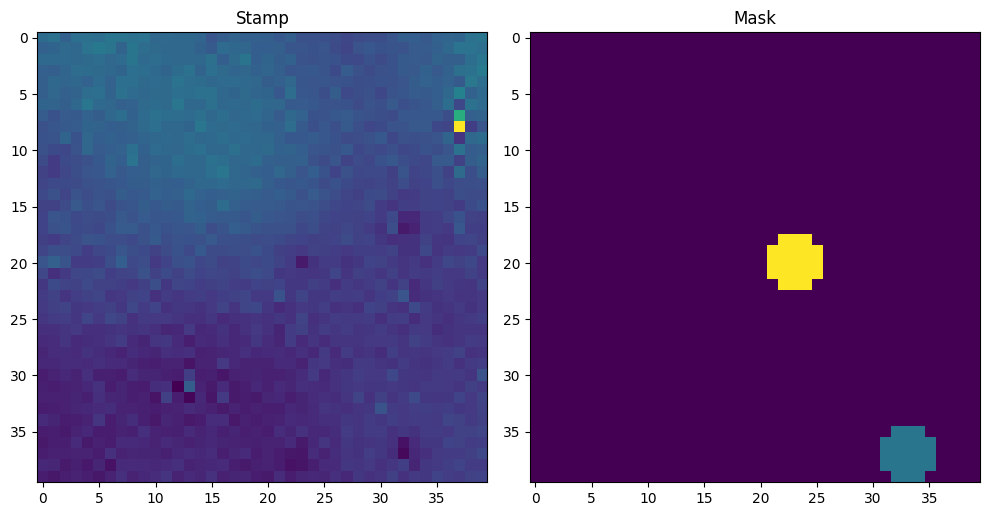

In [297]:
plot_mask_stamp()

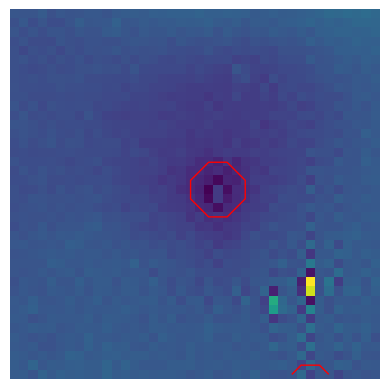

In [327]:
def show_random_image_pairs(dataset, n=5):

    for i in range(n):

        idx = random.randrange(len(dataset))
        img, mask = dataset[idx]
        # rearranging shapes
        img = img.squeeze()
        mask = mask.squeeze()

        # create subplot
        plt.subplot(1, n, i+1)

        # plot stamp
        plt.imshow(img[0])

        # overlay mask
        plt.contour(mask.astype(float), levels = [0.5], colors="red", linewidths=1)

        plt.axis(False)

show_random_image_pairs(dataset, n=1)